<a href="https://www.kaggle.com/code/lalit7881/india-cancer-patient-2022-25-97?scriptVersionId=327261654" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/ashyou09/india-cancer-patient-dataset-2022-2025/india_cancer_patients_2022_2025.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/ashyou09/india-cancer-patient-dataset-2022-2025/india_cancer_patients_2022_2025.csv")

In [3]:
df.head()

,Patient_ID,Age,Gender,State,City,Hospital_Name,Cancer_Type,Stage,Treatment_Type,Diagnosis_Date,Survival_Months,Status
0,IND-CAN-100000,82,Female,Delhi,New Delhi,Rajiv Gandhi Cancer Institute,Stomach Cancer,Stage III,Palliative Care,2024-06-05,3.5,Deceased
1,IND-CAN-100001,45,Female,West Bengal,Kolkata,Tata Medical Center,Cervical Cancer,Stage IV,Palliative Care,2023-08-12,34.0,Alive
2,IND-CAN-100002,47,Male,Chandigarh,Chandigarh,PGIMER,Oral Cancer,Stage III,Targeted Therapy,2023-09-09,33.0,Alive
3,IND-CAN-100003,1,Female,Delhi,New Delhi,AIIMS,Leukemia,Stage II,Palliative Care,2024-03-01,27.3,Alive
4,IND-CAN-100004,52,Female,Maharashtra,Mumbai,Tata Memorial Hospital,Cervical Cancer,Stage IV,Palliative Care,2022-05-17,24.0,Deceased


In [4]:
df.tail()

,Patient_ID,Age,Gender,State,City,Hospital_Name,Cancer_Type,Stage,Treatment_Type,Diagnosis_Date,Survival_Months,Status
99995,IND-CAN-199995,50,Female,Delhi,New Delhi,AIIMS,Breast Cancer,Stage III,Surgery + Chemotherapy,2023-12-03,17.7,Deceased
99996,IND-CAN-199996,32,Female,Karnataka,Bengaluru,Kidwai Memorial Institute of Oncology,Breast Cancer,Stage IV,Targeted Therapy,2025-04-12,6.3,Deceased
99997,IND-CAN-199997,92,Female,West Bengal,Kolkata,Tata Medical Center,Stomach Cancer,Stage II,Radiation,2024-09-06,21.1,Alive
99998,IND-CAN-199998,60,Female,Tamil Nadu,Chennai,Adyar Cancer Institute,Breast Cancer,Stage II,Palliative Care,2023-06-04,32.4,Deceased
99999,IND-CAN-199999,69,Female,Chandigarh,Chandigarh,PGIMER,Cervical Cancer,Stage IV,Palliative Care,2025-06-08,1.5,Deceased


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 12 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Patient_ID       100000 non-null  object 
 1   Age              100000 non-null  int64  
 2   Gender           100000 non-null  object 
 3   State            100000 non-null  object 
 4   City             100000 non-null  object 
 5   Hospital_Name    100000 non-null  object 
 6   Cancer_Type      100000 non-null  object 
 7   Stage            100000 non-null  object 
 8   Treatment_Type   100000 non-null  object 
 9   Diagnosis_Date   100000 non-null  object 
 10  Survival_Months  100000 non-null  float64
 11  Status           100000 non-null  object 
dtypes: float64(1), int64(1), object(10)
memory usage: 9.2+ MB


In [6]:
df.describe()

,Age,Survival_Months
count,100000.000000,100000.000000
mean,53.899460,20.333353
std,13.653781,14.156450
min,1.000000,1.000000
25%,45.000000,8.200000
50%,54.000000,17.200000
75%,63.000000,30.600000
max,95.000000,53.300000


In [7]:
df.isnull()

,Patient_ID,Age,Gender,State,City,Hospital_Name,Cancer_Type,Stage,Treatment_Type,Diagnosis_Date,Survival_Months,Status
0,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
99995,False,False,False,False,False,False,False,False,False,False,False,False
99996,False,False,False,False,False,False,False,False,False,False,False,False
99997,False,False,False,False,False,False,False,False,False,False,False,False
99998,False,False,False,False,False,False,False,False,False,False,False,False


In [8]:
df.isnull().sum()

Patient_ID         0
Age                0
Gender             0
State              0
City               0
Hospital_Name      0
Cancer_Type        0
Stage              0
Treatment_Type     0
Diagnosis_Date     0
Survival_Months    0
Status             0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.dtypes

Patient_ID          object
Age                  int64
Gender              object
State               object
City                object
Hospital_Name       object
Cancer_Type         object
Stage               object
Treatment_Type      object
Diagnosis_Date      object
Survival_Months    float64
Status              object
dtype: object

In [11]:
df.shape

(100000, 12)

In [12]:
df.columns

Index(['Patient_ID', 'Age', 'Gender', 'State', 'City', 'Hospital_Name',
       'Cancer_Type', 'Stage', 'Treatment_Type', 'Diagnosis_Date',
       'Survival_Months', 'Status'],
      dtype='object')

In [13]:
df.nunique()

Patient_ID         100000
Age                    95
Gender                  2
State                   9
City                    9
Hospital_Name          10
Cancer_Type             9
Stage                   4
Treatment_Type          7
Diagnosis_Date       1462
Survival_Months       524
Status                  2
dtype: int64

## EDA

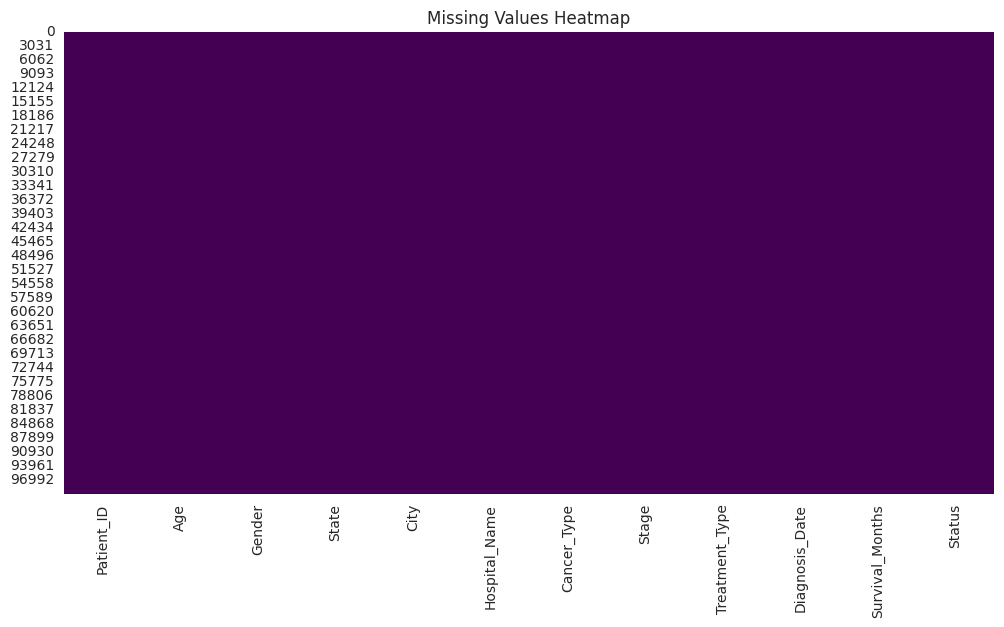

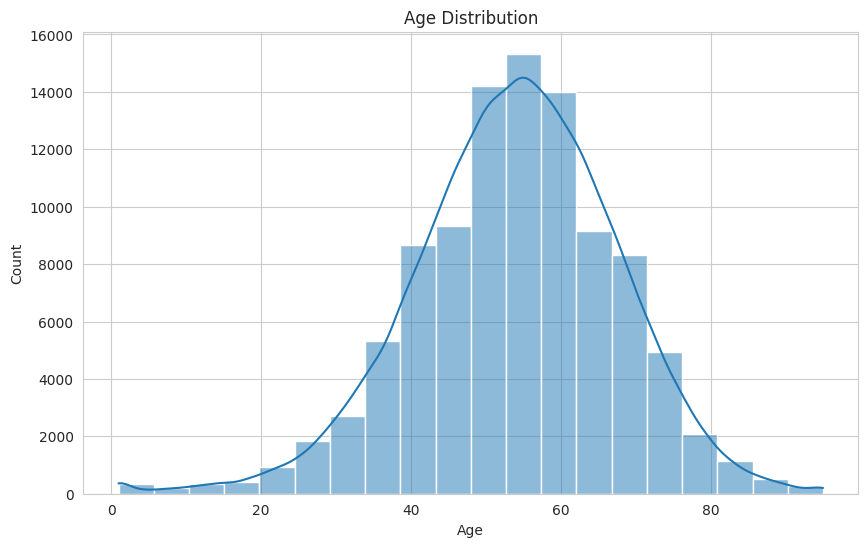

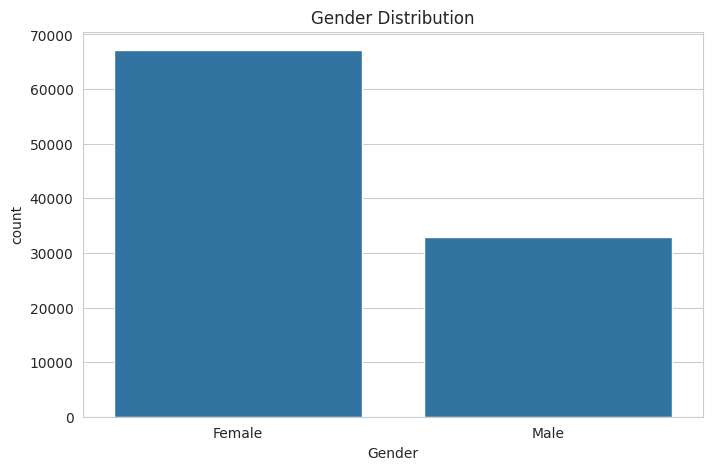

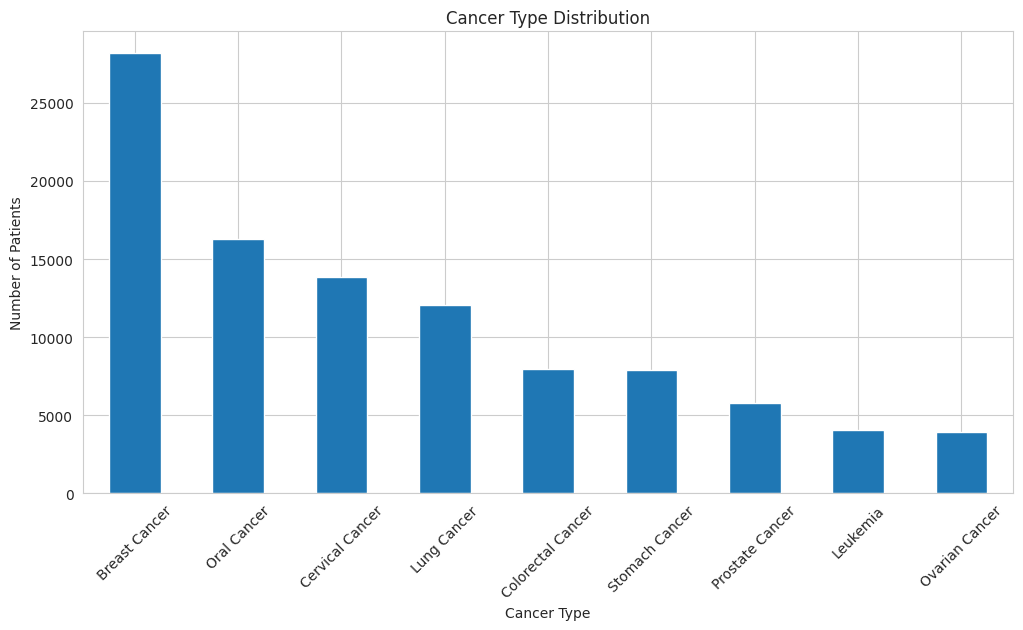

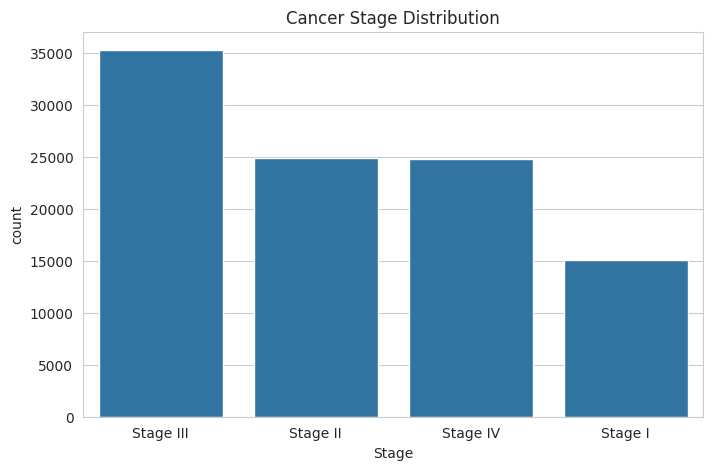

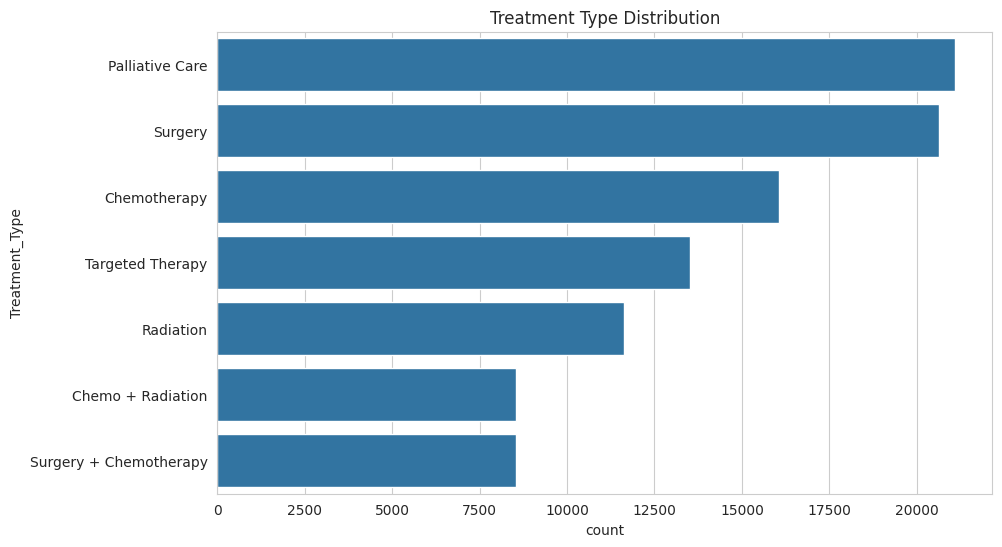

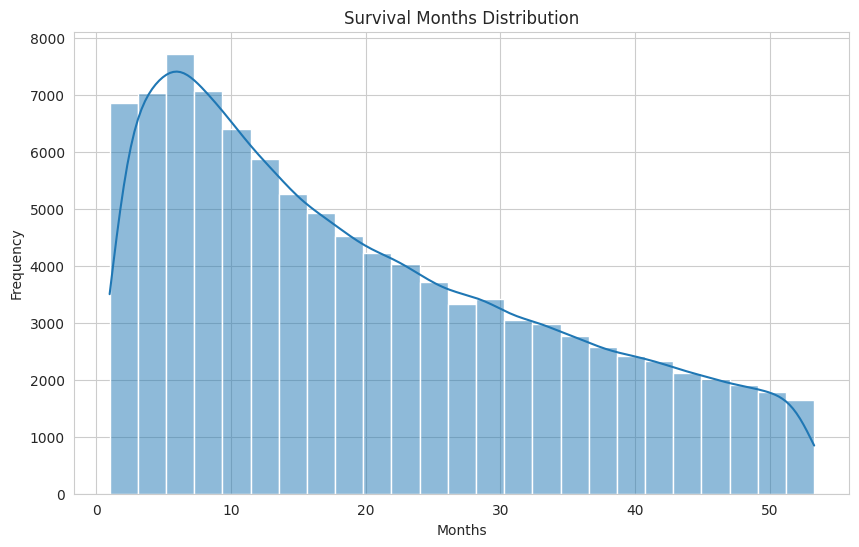

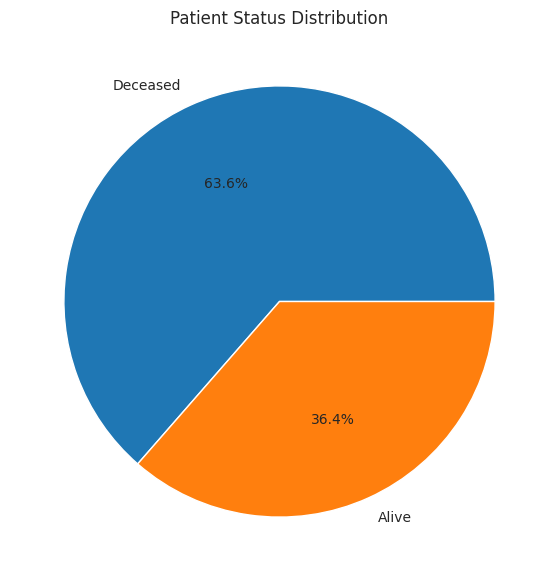

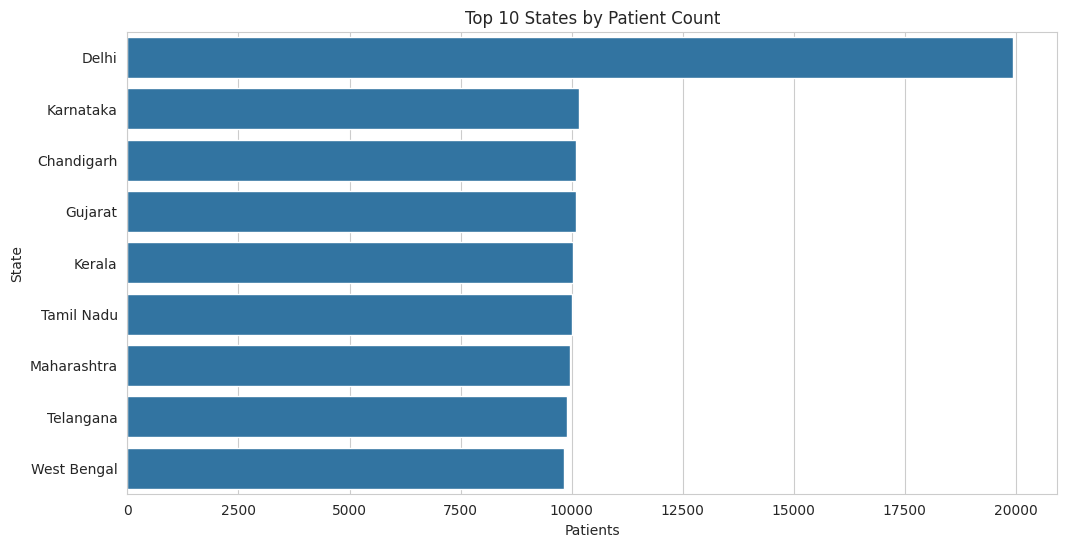

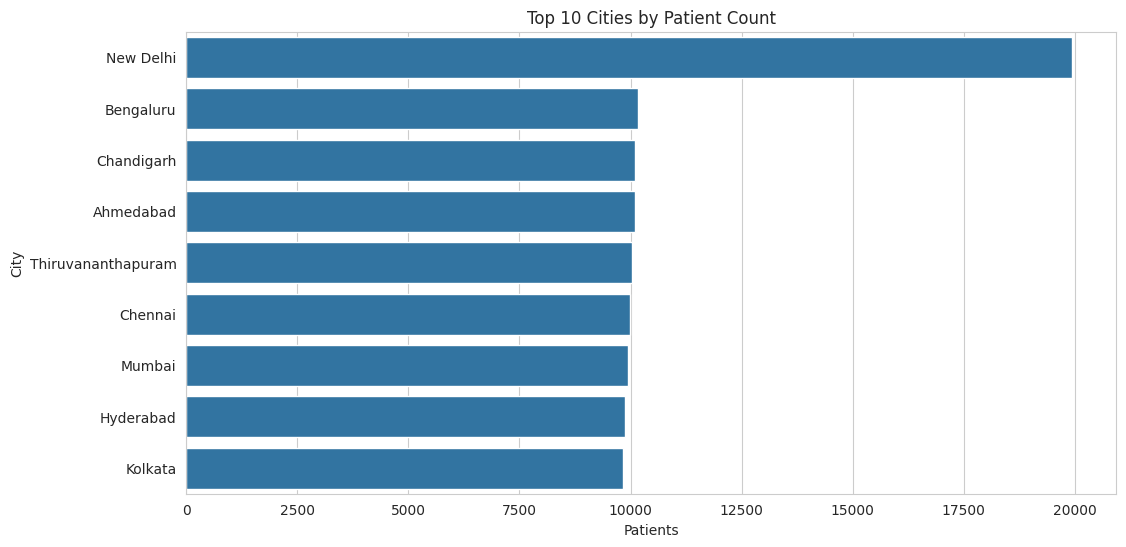

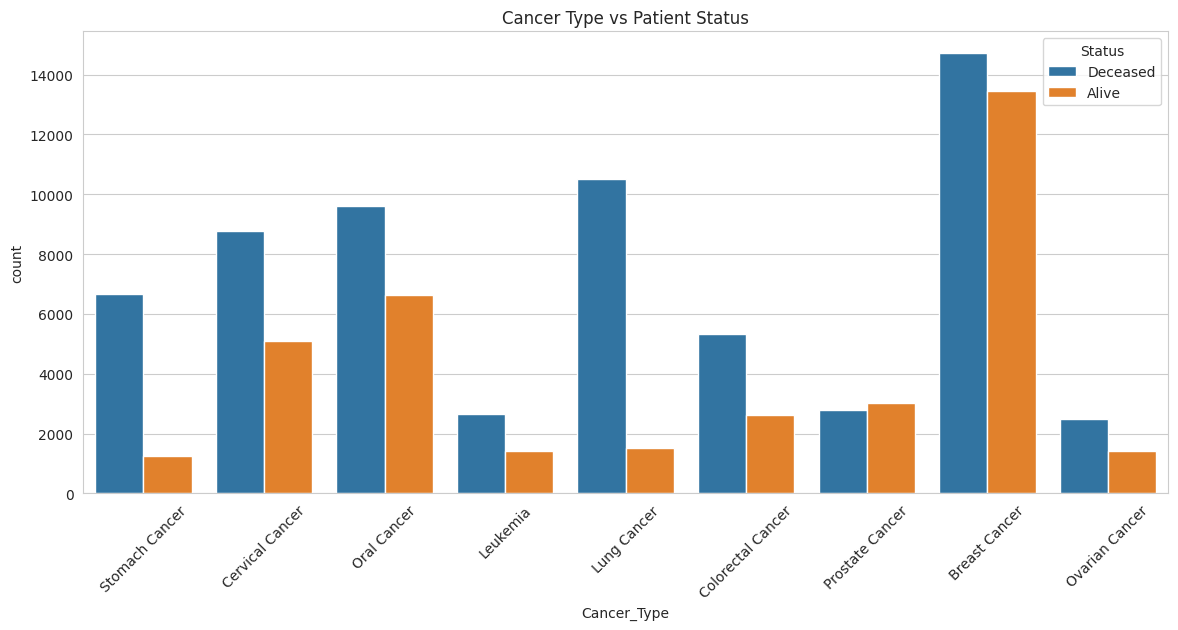

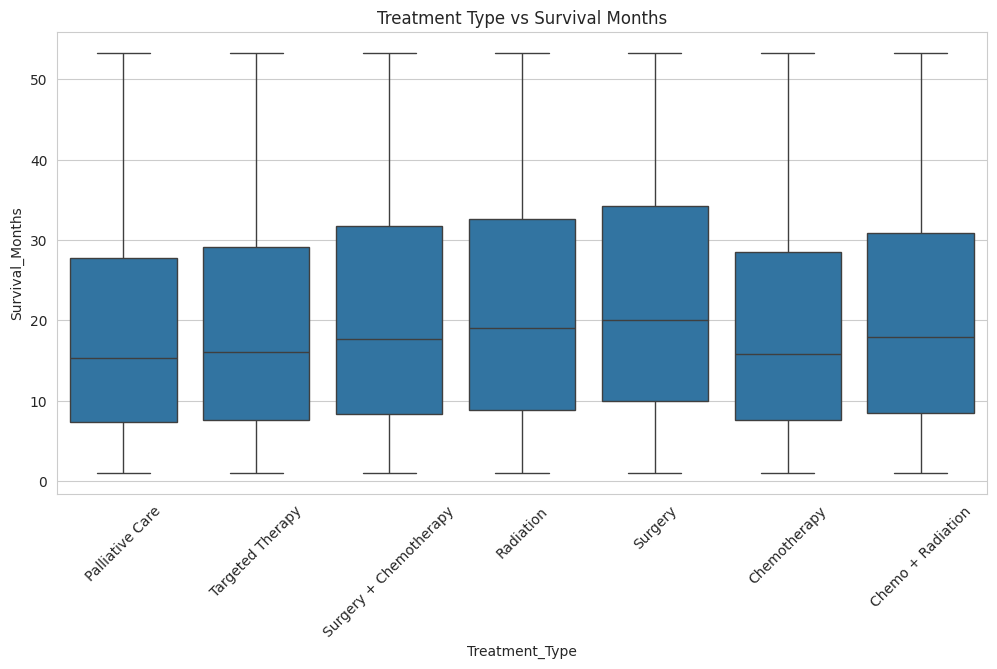

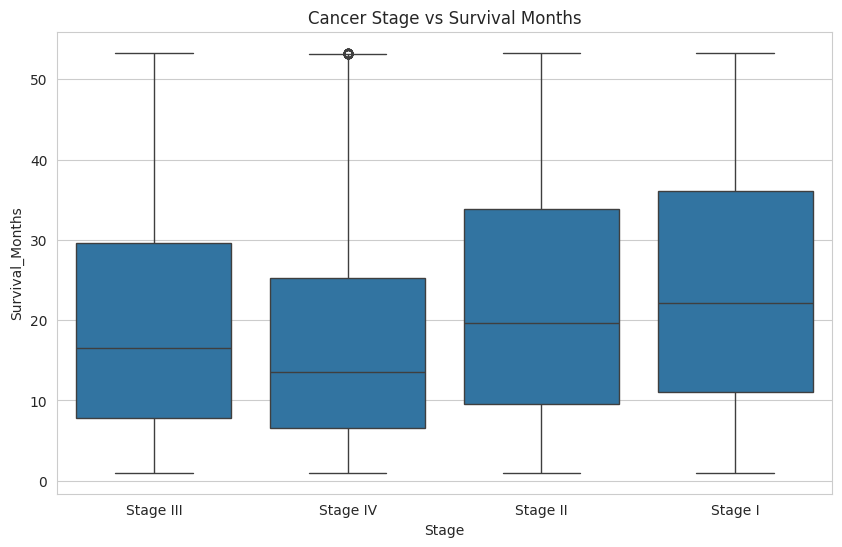

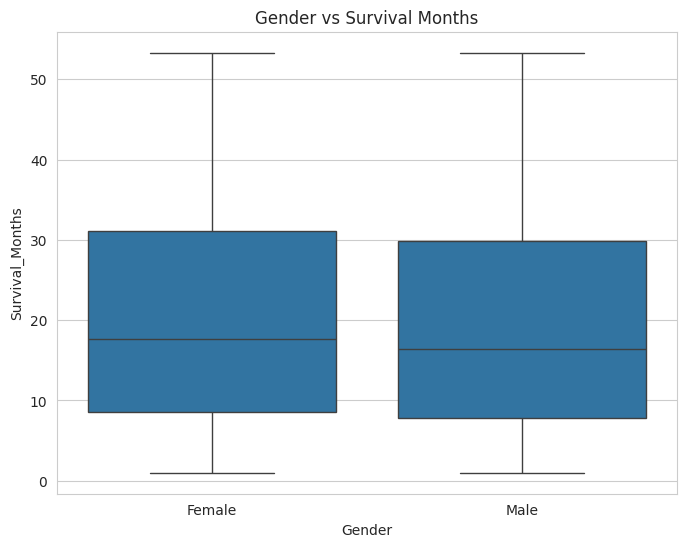

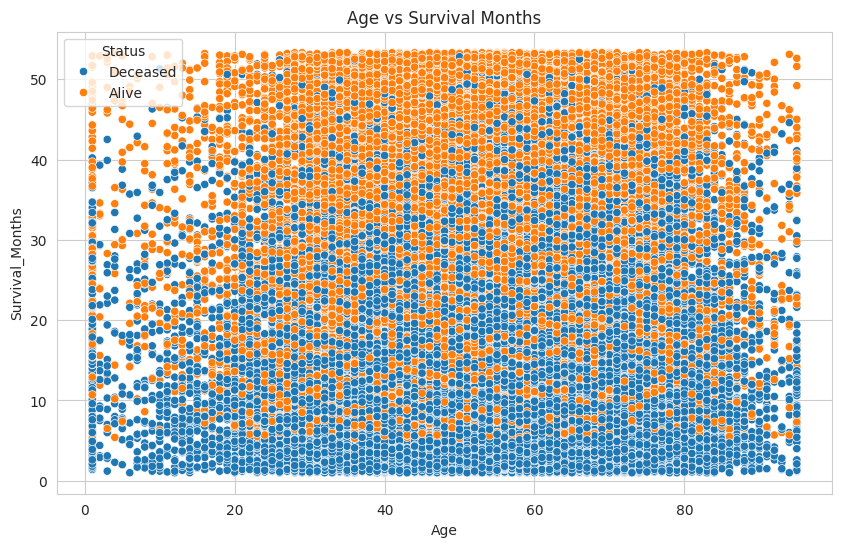

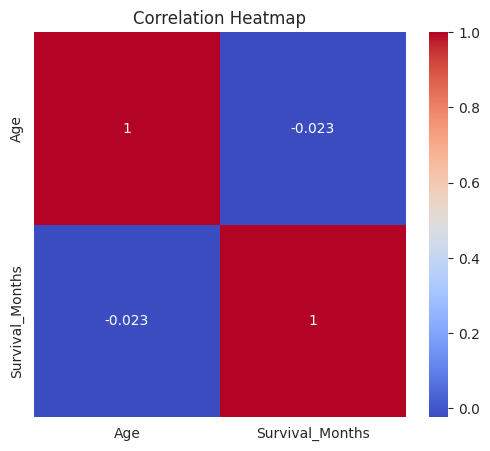

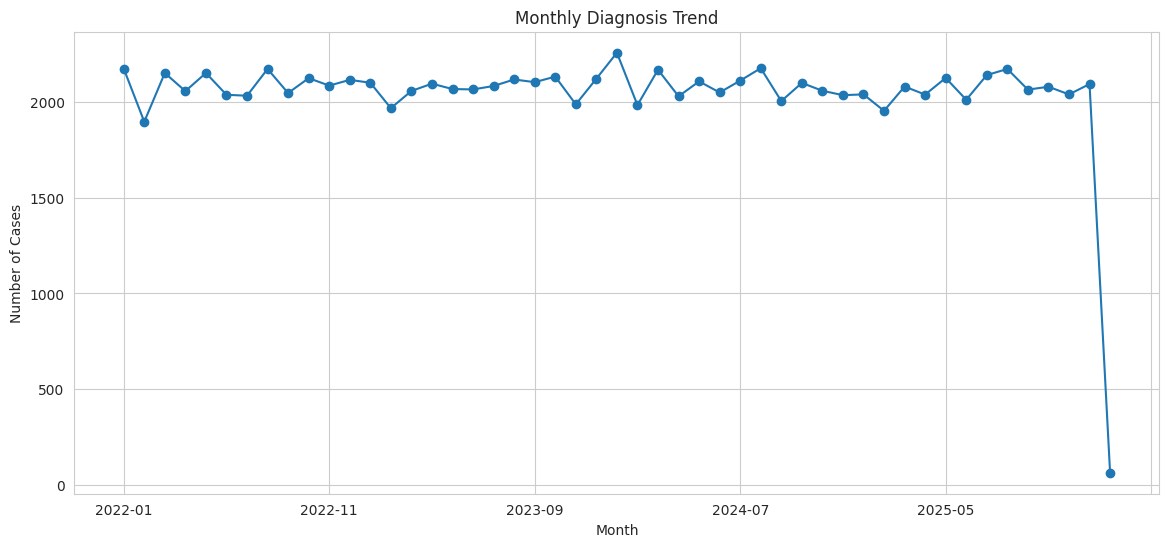

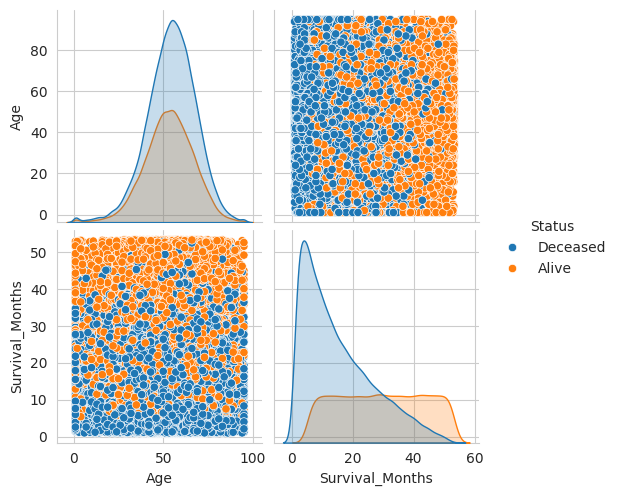

All visualizations generated successfully.


In [14]:
# Visualization Style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10,6)

# ==========================================
# 1. Missing Values Heatmap
# ==========================================

plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

# ==========================================
# 2. Age Distribution
# ==========================================

plt.figure(figsize=(10,6))
sns.histplot(df['Age'], bins=20, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

# ==========================================
# 3. Gender Distribution
# ==========================================

plt.figure(figsize=(8,5))
sns.countplot(x='Gender', data=df)
plt.title("Gender Distribution")
plt.show()

# ==========================================
# 4. Top Cancer Types
# ==========================================

plt.figure(figsize=(12,6))
df['Cancer_Type'].value_counts().plot(kind='bar')
plt.title("Cancer Type Distribution")
plt.xlabel("Cancer Type")
plt.ylabel("Number of Patients")
plt.xticks(rotation=45)
plt.show()

# ==========================================
# 5. Cancer Stage Distribution
# ==========================================

plt.figure(figsize=(8,5))
sns.countplot(x='Stage', data=df,
              order=df['Stage'].value_counts().index)
plt.title("Cancer Stage Distribution")
plt.show()

# ==========================================
# 6. Treatment Type Distribution
# ==========================================

plt.figure(figsize=(10,6))
sns.countplot(y='Treatment_Type',
              data=df,
              order=df['Treatment_Type'].value_counts().index)
plt.title("Treatment Type Distribution")
plt.show()

# ==========================================
# 7. Survival Months Distribution
# ==========================================

plt.figure(figsize=(10,6))
sns.histplot(df['Survival_Months'],
             bins=25,
             kde=True)

plt.title("Survival Months Distribution")
plt.xlabel("Months")
plt.ylabel("Frequency")
plt.show()

# ==========================================
# 8. Status Distribution
# ==========================================

plt.figure(figsize=(7,7))
df['Status'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Patient Status Distribution")
plt.ylabel("")
plt.show()

# ==========================================
# 9. Top States by Number of Patients
# ==========================================

top_states = df['State'].value_counts().head(10)

plt.figure(figsize=(12,6))
sns.barplot(
    x=top_states.values,
    y=top_states.index
)

plt.title("Top 10 States by Patient Count")
plt.xlabel("Patients")
plt.ylabel("State")
plt.show()

# ==========================================
# 10. Top Cities by Number of Patients
# ==========================================

top_cities = df['City'].value_counts().head(10)

plt.figure(figsize=(12,6))
sns.barplot(
    x=top_cities.values,
    y=top_cities.index
)

plt.title("Top 10 Cities by Patient Count")
plt.xlabel("Patients")
plt.ylabel("City")
plt.show()

# ==========================================
# 11. Cancer Type vs Status
# ==========================================

plt.figure(figsize=(14,6))

sns.countplot(
    x='Cancer_Type',
    hue='Status',
    data=df
)

plt.xticks(rotation=45)
plt.title("Cancer Type vs Patient Status")
plt.show()

# ==========================================
# 12. Treatment Type vs Survival Months
# ==========================================

plt.figure(figsize=(12,6))

sns.boxplot(
    x='Treatment_Type',
    y='Survival_Months',
    data=df
)

plt.xticks(rotation=45)
plt.title("Treatment Type vs Survival Months")
plt.show()

# ==========================================
# 13. Stage vs Survival Months
# ==========================================

plt.figure(figsize=(10,6))

sns.boxplot(
    x='Stage',
    y='Survival_Months',
    data=df
)

plt.title("Cancer Stage vs Survival Months")
plt.show()

# ==========================================
# 14. Gender vs Survival Months
# ==========================================

plt.figure(figsize=(8,6))

sns.boxplot(
    x='Gender',
    y='Survival_Months',
    data=df
)

plt.title("Gender vs Survival Months")
plt.show()

# ==========================================
# 15. Age vs Survival Months
# ==========================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    x='Age',
    y='Survival_Months',
    hue='Status',
    data=df
)

plt.title("Age vs Survival Months")
plt.show()

# ==========================================
# 16. Correlation Heatmap
# ==========================================

numeric_cols = ['Age', 'Survival_Months']

corr = df[numeric_cols].corr()

plt.figure(figsize=(6,5))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

# ==========================================
# 17. Monthly Diagnosis Trend
# ==========================================

df['Diagnosis_Date'] = pd.to_datetime(
    df['Diagnosis_Date'],
    errors='coerce'
)

monthly_cases = (
    df.groupby(
        df['Diagnosis_Date'].dt.to_period('M')
    ).size()
)

monthly_cases.index = monthly_cases.index.astype(str)

plt.figure(figsize=(14,6))
monthly_cases.plot(marker='o')

plt.title("Monthly Diagnosis Trend")
plt.xlabel("Month")
plt.ylabel("Number of Cases")
plt.grid(True)
plt.show()

# ==========================================
# 18. Pairplot
# ==========================================

sns.pairplot(
    df[['Age',
        'Survival_Months',
        'Status']],
    hue='Status'
)

plt.show()

print("All visualizations generated successfully.")

## Feature engineering

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier

Target Classes:
0 = Alive
1 = Deceased

Train Shape: (80000, 12)
Test Shape : (20000, 12)

Logistic Regression

Accuracy : 0.7842
Precision: 0.7808
Recall   : 0.7842
F1 Score : 0.7807
ROC AUC  : 0.857

Classification Report:

              precision    recall  f1-score   support

           0       0.73      0.64      0.68      7285
           1       0.81      0.87      0.84     12715

    accuracy                           0.78     20000
   macro avg       0.77      0.75      0.76     20000
weighted avg       0.78      0.78      0.78     20000


Decision Tree

Accuracy : 0.9733
Precision: 0.9733
Recall   : 0.9733
F1 Score : 0.9733
ROC AUC  : 0.9718

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.97      0.96      7285
           1       0.98      0.98      0.98     12715

    accuracy                           0.97     20000
   macro avg       0.97      0.97      0.97     20000
weighted avg       0.97      0.97      0.97 

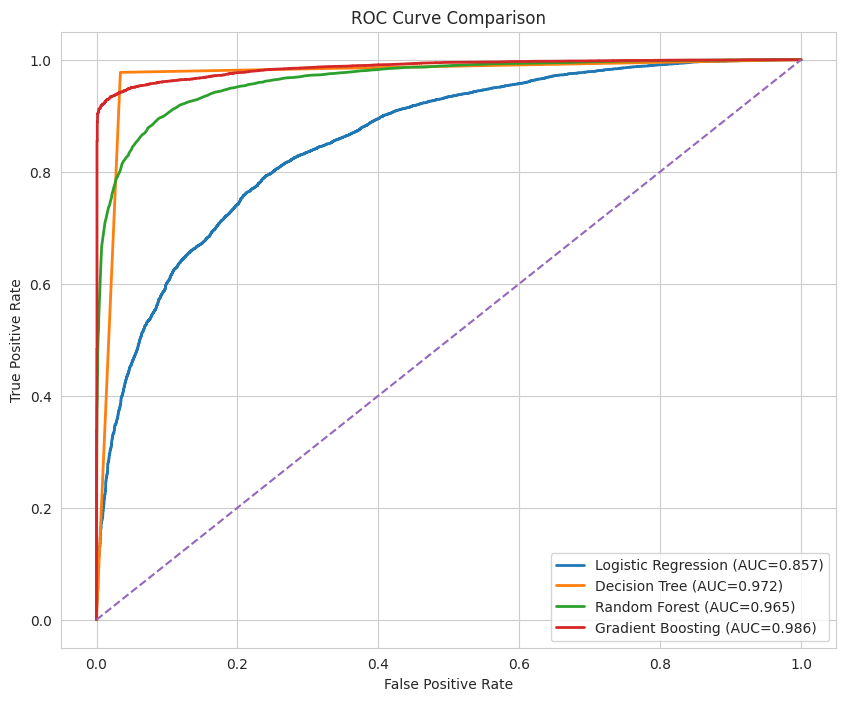



MODEL COMPARISON
                 Model  Accuracy  Precision   Recall  F1 Score   ROC AUC
3    Gradient Boosting   0.94970   0.953249  0.94970  0.950158  0.986457
1        Decision Tree   0.97330   0.973339  0.97330  0.973316  0.971761
2        Random Forest   0.90275   0.902312  0.90275  0.902395  0.964991
0  Logistic Regression   0.78420   0.780767  0.78420  0.780722  0.857002

Best Model:
Model        Gradient Boosting
Accuracy                0.9497
Precision             0.953249
Recall                  0.9497
F1 Score              0.950158
ROC AUC               0.986457
Name: 3, dtype: object


In [16]:


df['Diagnosis_Date'] = pd.to_datetime(
    df['Diagnosis_Date'],
    errors='coerce'
)

df['Diagnosis_Year'] = df['Diagnosis_Date'].dt.year
df['Diagnosis_Month'] = df['Diagnosis_Date'].dt.month
df['Diagnosis_Day'] = df['Diagnosis_Date'].dt.day

df.drop('Diagnosis_Date', axis=1, inplace=True)


df.drop('Patient_ID', axis=1, inplace=True)


target = 'Status'

X = df.drop(target, axis=1)
y = df[target]


le = LabelEncoder()

y = le.fit_transform(y)

print("Target Classes:")
for i, cls in enumerate(le.classes_):
    print(i, "=", cls)


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTrain Shape:", X_train.shape)
print("Test Shape :", X_test.shape)


cat_cols = X_train.select_dtypes(
    include=['object']
).columns

num_cols = X_train.select_dtypes(
    exclude=['object']
).columns


numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, num_cols),
    ('cat', categorical_transformer, cat_cols)
])


models = {
    "Logistic Regression":
        LogisticRegression(max_iter=500),

    "Decision Tree":
        DecisionTreeClassifier(random_state=42),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ),

    "Gradient Boosting":
        GradientBoostingClassifier(
            random_state=42
        )
}


results = []

plt.figure(figsize=(10,8))

for name, model in models.items():

    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    # Train
    pipeline.fit(X_train, y_train)

    # Prediction
    y_pred = pipeline.predict(X_test)

    # Probability
    y_prob = pipeline.predict_proba(X_test)[:,1]

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        average='weighted'
    )

    recall = recall_score(
        y_test,
        y_pred,
        average='weighted'
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average='weighted'
    )

    roc_auc = roc_auc_score(
        y_test,
        y_prob
    )

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ])

    print("\n" + "="*50)
    print(name)
    print("="*50)

    print("\nAccuracy :", round(accuracy,4))
    print("Precision:", round(precision,4))
    print("Recall   :", round(recall,4))
    print("F1 Score :", round(f1,4))
    print("ROC AUC  :", round(roc_auc,4))

    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    plt.plot(
        fpr,
        tpr,
        lw=2,
        label=f'{name} (AUC={roc_auc:.3f})'
    )


plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(True)
plt.show()


results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ]
)

results_df = results_df.sort_values(
    by='ROC AUC',
    ascending=False
)

print("\n")
print("="*70)
print("MODEL COMPARISON")
print("="*70)

print(results_df)



best_model = results_df.iloc[0]

print("\nBest Model:")
print(best_model)

## Thank you...pls upvote!!!!!!!!!!!!!